# Week 3 Assignment: Customer Intelligence System

**Objective:** Develop an end-to-end Customer Intelligence System using classification, ensemble learning, and clustering.

This notebook covers:
- Data loading / synthetic customer dataset creation
- Data preprocessing and EDA
- Classification using Random Forest and XGBoost
- Model evaluation and hyperparameter tuning
- Customer segmentation using K-Means and DBSCAN
- Actionable customer insights


## 1. Install and Import Libraries

In [ ]:
# Install XGBoost if needed
!pip -q install xgboost

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print('XGBoost not available:', e)

np.random.seed(42)

## 2. Create / Load Customer Dataset

For this assignment, a realistic customer dataset is created with customer behaviour features. The target variable is **Purchased**, which shows whether the customer purchased a product or not.

In [ ]:
# Synthetic customer dataset for Customer Intelligence System
n = 1000

age = np.random.randint(18, 66, n)
income = np.random.normal(55000, 18000, n).clip(15000, 150000)
website_visits = np.random.poisson(8, n)
time_spent = np.random.normal(25, 10, n).clip(2, 80)
previous_purchases = np.random.poisson(3, n)
cart_value = np.random.normal(250, 120, n).clip(20, 1000)
support_calls = np.random.poisson(1, n)
email_click_rate = np.random.beta(2, 5, n)
loyalty_score = np.random.randint(1, 101, n)

# Purchase probability based on customer behaviour
score = (
    0.03 * website_visits +
    0.04 * previous_purchases +
    0.01 * time_spent +
    0.006 * loyalty_score +
    1.5 * email_click_rate +
    0.000006 * income -
    0.05 * support_calls -
    1.2
)
probability = 1 / (1 + np.exp(-score))
purchased = (probability > np.random.rand(n)).astype(int)

df = pd.DataFrame({
    'Age': age,
    'Annual_Income': income.round(2),
    'Website_Visits': website_visits,
    'Time_Spent_Minutes': time_spent.round(2),
    'Previous_Purchases': previous_purchases,
    'Cart_Value': cart_value.round(2),
    'Support_Calls': support_calls,
    'Email_Click_Rate': email_click_rate.round(3),
    'Loyalty_Score': loyalty_score,
    'Purchased': purchased
})

df.head()

,Age,Annual_Income,Website_Visits,Time_Spent_Minutes,Previous_Purchases,Cart_Value,Support_Calls,Email_Click_Rate,Loyalty_Score,Purchased
0,56,25704.24,5,37.30,3,142.77,2,0.264,70,0
1,46,55865.53,6,30.27,0,440.43,1,0.167,100,0
2,32,59675.01,8,29.46,0,20.00,1,0.011,50,0
3,60,38722.30,11,7.78,1,233.18,0,0.467,88,1
4,25,66494.66,5,17.80,2,390.67,0,0.004,67,1


## 3. Basic Data Inspection

In [ ]:
print('Dataset shape:', df.shape)
print('Missing values:')
print(df.isnull().sum())
print('Duplicate rows:', df.duplicated().sum())
df.describe().T

Dataset shape: (1000, 10)
Missing values:
Age                   0
Annual_Income         0
Website_Visits        0
Time_Spent_Minutes    0
Previous_Purchases    0
Cart_Value            0
Support_Calls         0
Email_Click_Rate      0
Loyalty_Score         0
Purchased             0
dtype: int64
Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
Age,1000.0,41.575000,13.765677,18.000,30.0000,42.0000,53.0000,65.000
Annual_Income,1000.0,56467.159360,17736.721963,15000.000,44599.6075,56224.3650,67770.8725,102382.880
Website_Visits,1000.0,7.888000,2.600427,1.000,6.0000,8.0000,10.0000,16.000
Time_Spent_Minutes,1000.0,25.183240,9.596801,2.000,18.8375,25.2700,31.6625,56.580
Previous_Purchases,1000.0,2.950000,1.805203,0.000,2.0000,3.0000,4.0000,10.000
Cart_Value,1000.0,256.089550,120.961864,20.000,171.0150,258.2600,338.1575,661.470
Support_Calls,1000.0,1.076000,1.063652,0.000,0.0000,1.0000,2.0000,5.000
Email_Click_Rate,1000.0,0.277957,0.156923,0.004,0.1510,0.2505,0.3770,0.802
Loyalty_Score,1000.0,50.806000,29.529449,1.000,25.0000,50.0000,77.0000,100.000
Purchased,1000.0,0.599000,0.490346,0.000,0.0000,1.0000,1.0000,1.000


## 4. Exploratory Data Analysis (EDA)

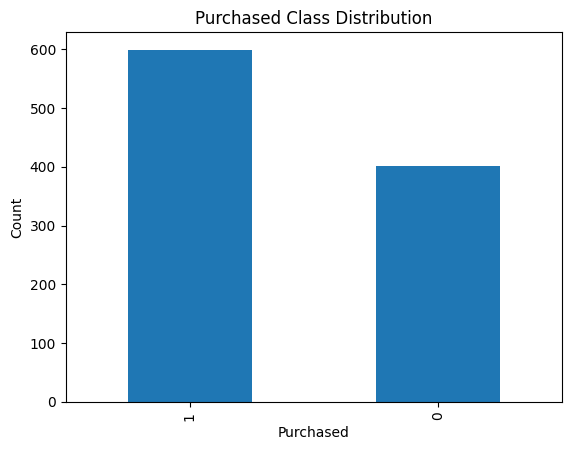

In [ ]:
# Target distribution
df['Purchased'].value_counts().plot(kind='bar')
plt.title('Purchased Class Distribution')
plt.xlabel('Purchased')
plt.ylabel('Count')
plt.show()

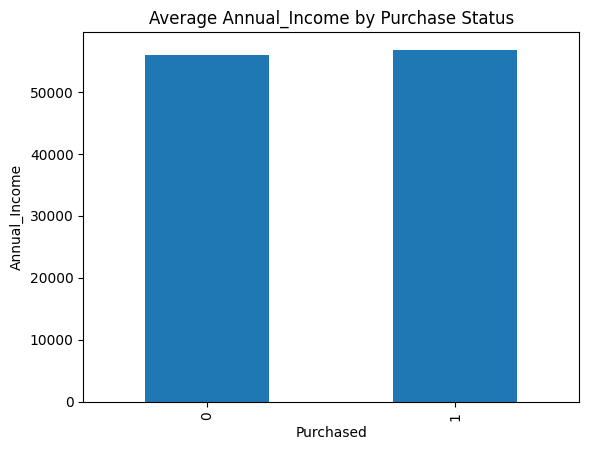

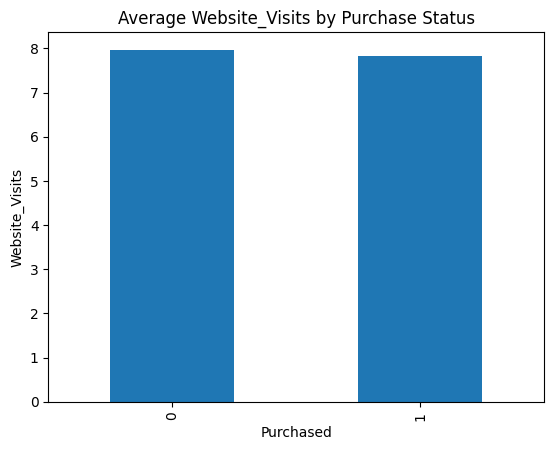

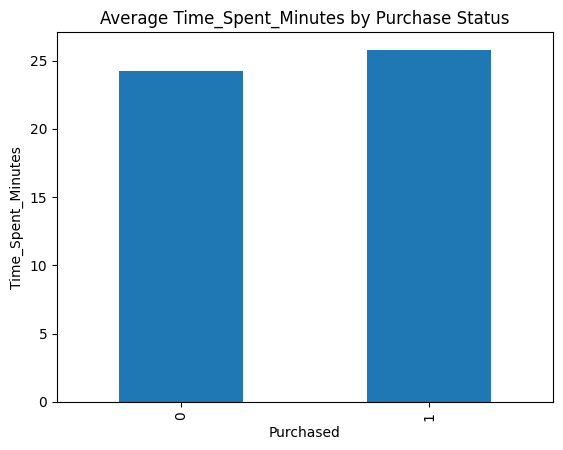

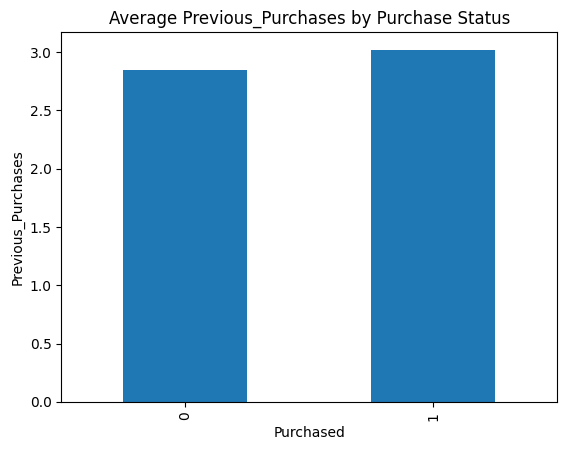

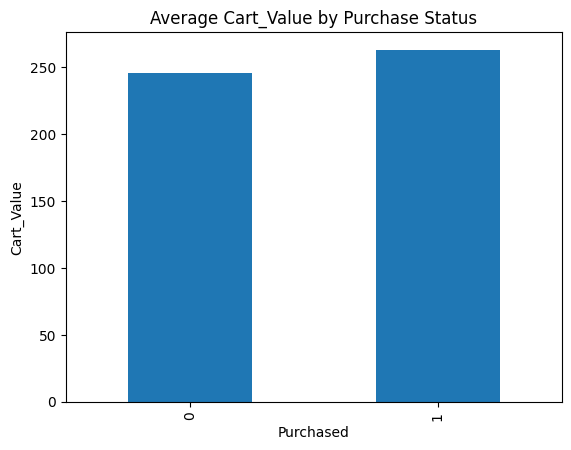

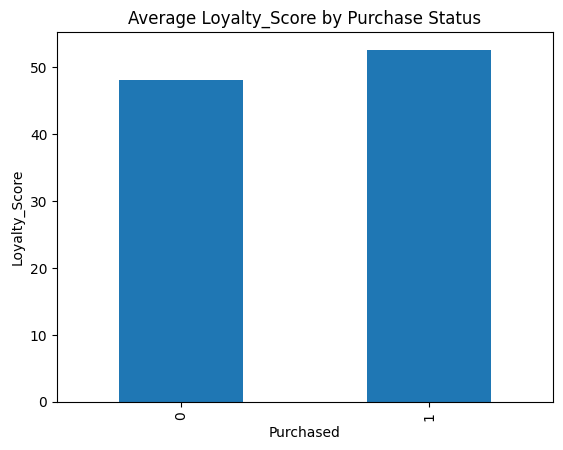

In [ ]:
# Relationship between features and purchase
features_to_plot = ['Annual_Income', 'Website_Visits', 'Time_Spent_Minutes', 'Previous_Purchases', 'Cart_Value', 'Loyalty_Score']

for col in features_to_plot:
    df.groupby('Purchased')[col].mean().plot(kind='bar')
    plt.title(f'Average {col} by Purchase Status')
    plt.xlabel('Purchased')
    plt.ylabel(col)
    plt.show()

In [ ]:
# Correlation with target
correlation = df.corr(numeric_only=True)['Purchased'].sort_values(ascending=False)
print(correlation)

Purchased             1.000000
Email_Click_Rate      0.148248
Time_Spent_Minutes    0.077421
Loyalty_Score         0.074953
Cart_Value            0.071324
Previous_Purchases    0.047439
Annual_Income         0.022299
Age                  -0.016376
Website_Visits       -0.025052
Support_Calls        -0.025956
Name: Purchased, dtype: float64


## 5. Data Preprocessing

- Separate features and target
- Split data into training and testing sets
- Apply feature scaling

In [ ]:
X = df.drop('Purchased', axis=1)
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 800
Testing samples: 200


## 6. Classification Model 1: Random Forest

In [ ]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))
print('Classification Report:', classification_report(y_test, rf_pred))
print('Confusion Matrix:', confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.585
Classification Report:               precision    recall  f1-score   support

           0       0.47      0.30      0.37        80
           1       0.62      0.78      0.69       120

    accuracy                           0.58       200
   macro avg       0.55      0.54      0.53       200
weighted avg       0.56      0.58      0.56       200

Confusion Matrix: [[24 56]
 [27 93]]


## 7. Classification Model 2: XGBoost

In [ ]:
if XGBOOST_AVAILABLE:
    xgb_model = XGBClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        eval_metric='logloss'
    )
    xgb_model.fit(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)

    print('XGBoost Accuracy:', accuracy_score(y_test, xgb_pred))
    print('Classification Report:', classification_report(y_test, xgb_pred))
    print('Confusion Matrix:', confusion_matrix(y_test, xgb_pred))
else:
    print('XGBoost is not available. Random Forest results can be used for evaluation.')

XGBoost Accuracy: 0.57
Classification Report:               precision    recall  f1-score   support

           0       0.43      0.25      0.32        80
           1       0.61      0.78      0.69       120

    accuracy                           0.57       200
   macro avg       0.52      0.52      0.50       200
weighted avg       0.54      0.57      0.54       200

Confusion Matrix: [[20 60]
 [26 94]]


## 8. Hyperparameter Tuning for Random Forest

In [ ]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [4, 6, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test)

print('Best Parameters:', grid_search.best_params_)
print('Tuned Random Forest Accuracy:', accuracy_score(y_test, best_pred))

Best Parameters: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 100}
Tuned Random Forest Accuracy: 0.605


## 9. Feature Importance

Feature importance helps us understand which customer features are more useful for prediction.

              Feature  Importance
7    Email_Click_Rate    0.200125
3  Time_Spent_Minutes    0.176086
5          Cart_Value    0.138303
8       Loyalty_Score    0.135917
1       Annual_Income    0.122660
0                 Age    0.088777
2      Website_Visits    0.062821
4  Previous_Purchases    0.050894
6       Support_Calls    0.024417


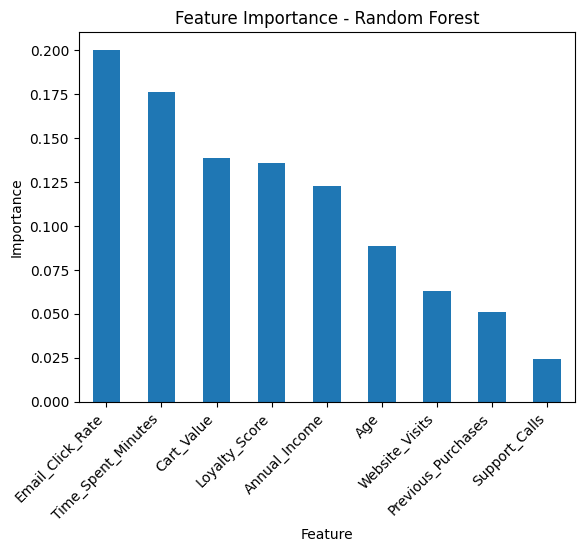

In [ ]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df)

importance_df.plot(x='Feature', y='Importance', kind='bar', legend=False)
plt.title('Feature Importance - Random Forest')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.show()

## 10. Customer Segmentation using K-Means

Here we use clustering to divide customers into groups based on similar behaviour.

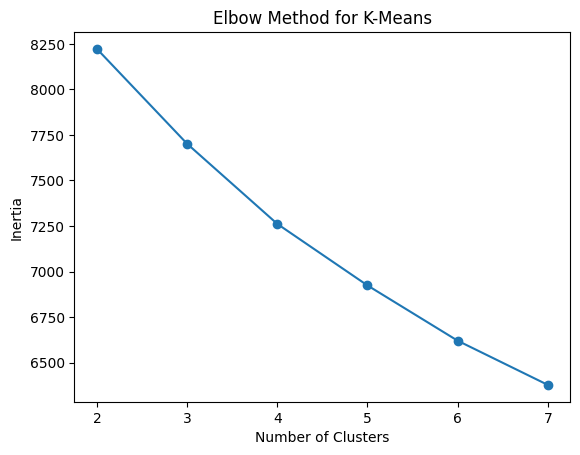

In [ ]:
cluster_features = df.drop('Purchased', axis=1)
cluster_scaled = scaler.fit_transform(cluster_features)

# Elbow method
inertias = []
K = range(2, 8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_scaled)
    inertias.append(km.inertia_)

plt.plot(list(K), inertias, marker='o')
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Segment'] = kmeans.fit_predict(cluster_scaled)

sil_kmeans = silhouette_score(cluster_scaled, df['KMeans_Segment'])
print('K-Means Silhouette Score:', sil_kmeans)
print('Segment counts:')
print(df['KMeans_Segment'].value_counts())

K-Means Silhouette Score: 0.08272195203602087
Segment counts:
KMeans_Segment
1    382
0    327
2    291
Name: count, dtype: int64


## 11. Customer Segmentation using DBSCAN

In [ ]:
dbscan = DBSCAN(eps=2.2, min_samples=8)
df['DBSCAN_Segment'] = dbscan.fit_predict(cluster_scaled)

print('DBSCAN segment counts:')
print(df['DBSCAN_Segment'].value_counts())

# Silhouette score only if more than one valid cluster exists
valid_labels = set(df['DBSCAN_Segment'])
if len(valid_labels) > 1 and not (len(valid_labels) == 2 and -1 in valid_labels):
    print('DBSCAN Silhouette Score:', silhouette_score(cluster_scaled, df['DBSCAN_Segment']))
else:
    print('DBSCAN did not form enough meaningful clusters for silhouette score.')

DBSCAN segment counts:
DBSCAN_Segment
 0    899
-1    101
Name: count, dtype: int64
DBSCAN did not form enough meaningful clusters for silhouette score.


## 12. PCA Visualization of Customer Segments

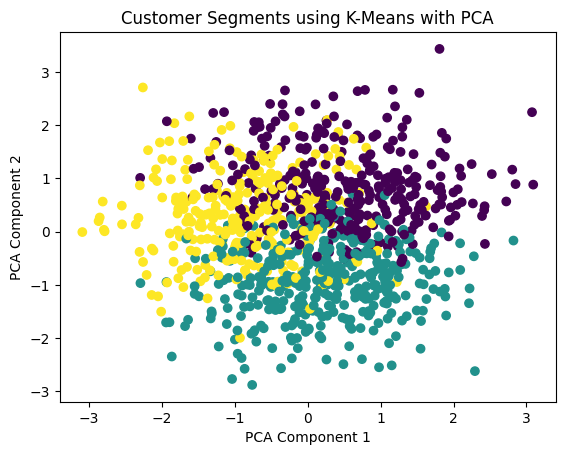

In [ ]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(cluster_scaled)

plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df['KMeans_Segment'])
plt.title('Customer Segments using K-Means with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

## 13. Segment Insights

In [ ]:
segment_summary = df.groupby('KMeans_Segment').agg({
    'Age': 'mean',
    'Annual_Income': 'mean',
    'Website_Visits': 'mean',
    'Time_Spent_Minutes': 'mean',
    'Previous_Purchases': 'mean',
    'Cart_Value': 'mean',
    'Loyalty_Score': 'mean',
    'Purchased': 'mean'
}).round(2)

segment_summary

,Age,Annual_Income,Website_Visits,Time_Spent_Minutes,Previous_Purchases,Cart_Value,Loyalty_Score,Purchased
KMeans_Segment,,,,,,,,
0,46.61,53205.91,8.72,22.34,3.83,333.52,55.91,0.60
1,31.73,56693.50,8.04,26.29,2.59,189.67,52.01,0.57
2,48.84,59834.75,6.76,26.93,2.43,256.27,43.49,0.64


## 14. Final Conclusion

In this Week 3 assignment, I developed a Customer Intelligence System using both supervised and unsupervised machine learning techniques. I used Random Forest and XGBoost for customer purchase prediction and K-Means and DBSCAN for customer segmentation. The classification models helped predict whether a customer is likely to purchase, while clustering helped group customers based on similar behaviour.

This assignment helped me understand classification, ensemble learning, clustering, model evaluation, hyperparameter tuning, and customer segmentation insights.